<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_MAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


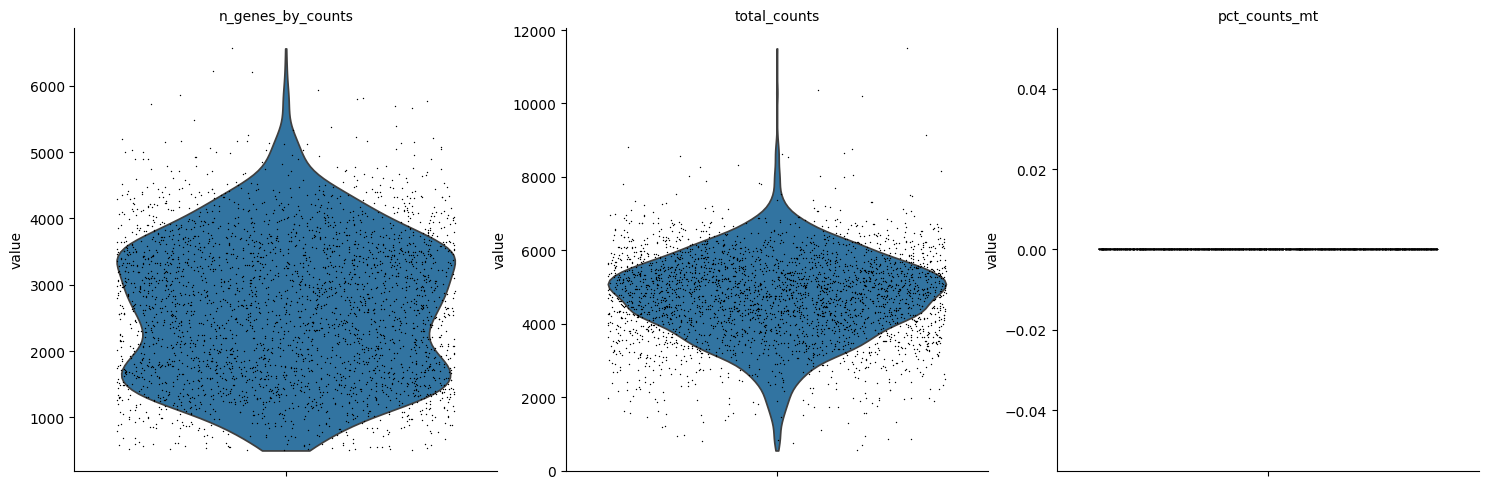

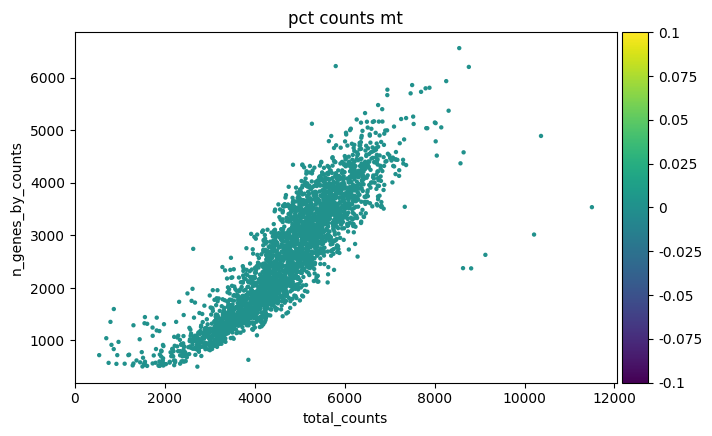

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


In [3]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-MAT.h5ad")
adata_aging.var['mt'] = adata_aging.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_aging, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(
    adata_aging,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    size=1
)
sc.pl.scatter(adata_aging, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')
print(list(adata_aging.obs.columns))

In [4]:
import scanpy as sc
adata_aging.var['mt'] = adata_aging.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_aging, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
print(f"Cells before QC: {adata_aging.n_obs}")
adata_aging = adata_aging[
    (adata_aging.obs.n_genes_by_counts < 4800) &
    (adata_aging.obs.n_genes_by_counts > 500),
    :
].copy()
print(f"Cells after QC: {adata_aging.n_obs}")

Cells before QC: 3014
Cells after QC: 2962


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
mesenchymal stem cell of adipose    1357
B cell                               364
endothelial cell                     253
macrophage                           225
myeloid cell                         221
Name: count, dtype: int64


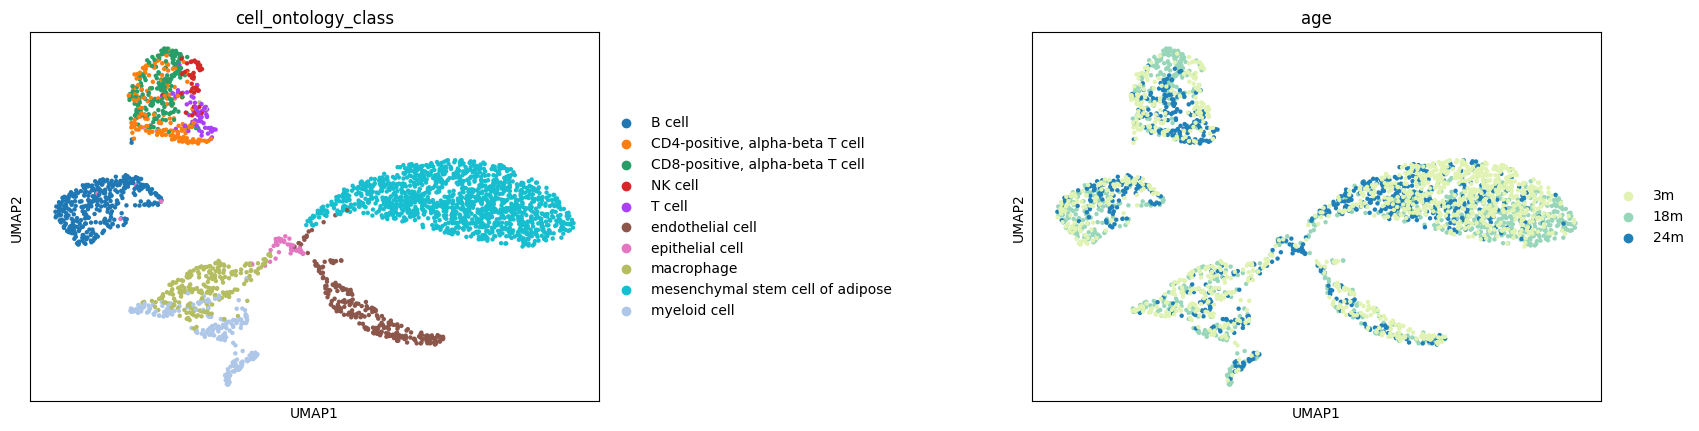

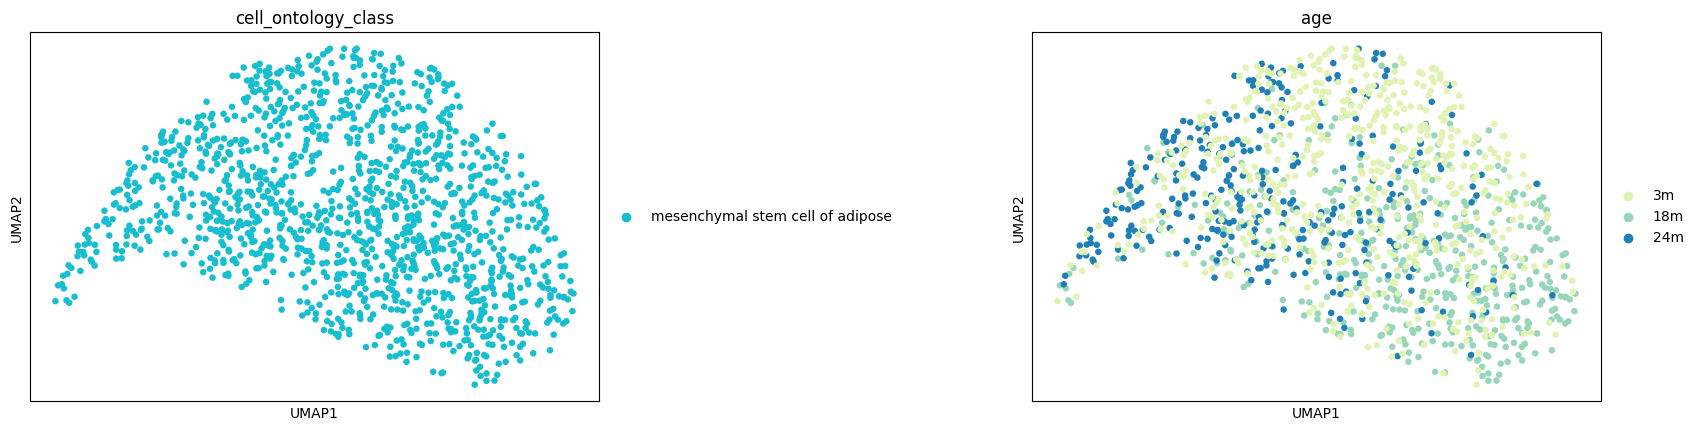

In [6]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
mesenchymal_stem_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'mesenchymal stem cell of adipose'].copy()
sc.pl.umap(mesenchymal_stem_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):
       18m_n     18m_l          18m_p
0      Snrpc  3.271004   7.074236e-36
1    Sult1e1  3.230292   6.156568e-10
2       Rtn1  2.940339   8.843024e-11
3   Npm3-ps1  2.613997   1.137239e-12
4        Aes  2.603688  1.261284e-104
5      Kdm6b  2.537529   1.009264e-73
6       Ptms  2.510277   8.203943e-75
7    Tnfsf12  2.478673   3.811281e-26
8       Sox9  2.477952   1.361488e-09
9     Lrrc8a  2.434525   2.072057e-58
10    Tmsb10  2.328300  3.097018e-129
11     Acsl4  2.254771   5.686194e-13
12      Jund  2.243318   1.269268e-86
13     Rspo3  2.218304   1.243007e-13
14      Cfl1  2.208636  5.457530e-130
15      Rhoc  2.155695   5.526976e-71
16     Sf3b4  2.128381   1.241787e-13
17     Sf3a2  2.125204   5.734671e-06
18       Wt1  2.087158   6.831500e-13
19     Pla1a  2.075122   4.785475e-17


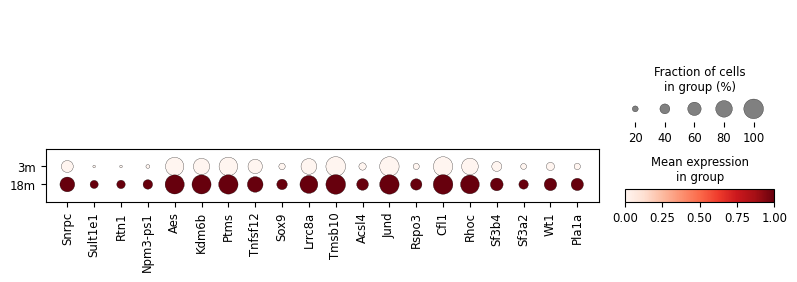

Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):
      18m_n     18m_l         18m_p
0     Krt14 -8.389300  3.844352e-06
1      C1qb -6.363960  2.387816e-07
2    S100a8 -4.160303  8.907944e-12
3      Plp1 -3.716408  1.709709e-06
4      Peg3 -3.489405  1.087597e-25
5    S100a9 -3.277516  1.462904e-07
6     Lars2 -3.146296  2.903027e-51
7    Mir703 -2.983210  4.024947e-22
8     Epha3 -2.802194  2.174110e-07
9     Nr1d1 -2.795506  1.828156e-16
10   Shisa3 -2.622792  3.494040e-06
11    Abcc9 -2.549817  1.850909e-11
12   Chrdl1 -2.463960  1.919852e-06
13   Egflam -2.421206  5.560884e-12
14  Tspan11 -2.392922  1.062292e-13
15    Ntrk2 -2.270074  2.033548e-09
16   Pdgfrl -2.013982  4.738629e-07
17    Bace2 -1.970781  1.706130e-06
18    Itm2a -1.960922  2.427211e-35
19     Lyz2 -1.891378  9.038885e-27


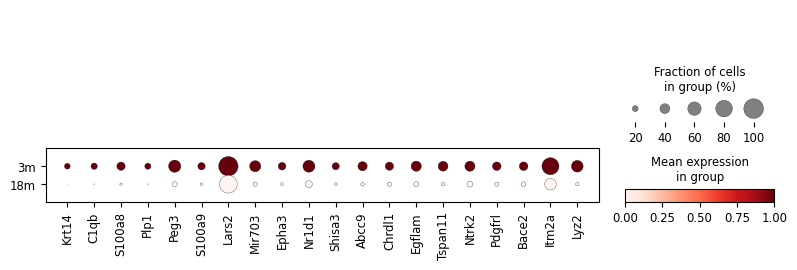

In [7]:
import pandas as pd
sc.tl.rank_genes_groups(
    mesenchymal_stem_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = mesenchymal_stem_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.5) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = mesenchymal_stem_cells[mesenchymal_stem_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.5) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = mesenchymal_stem_cells[mesenchymal_stem_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

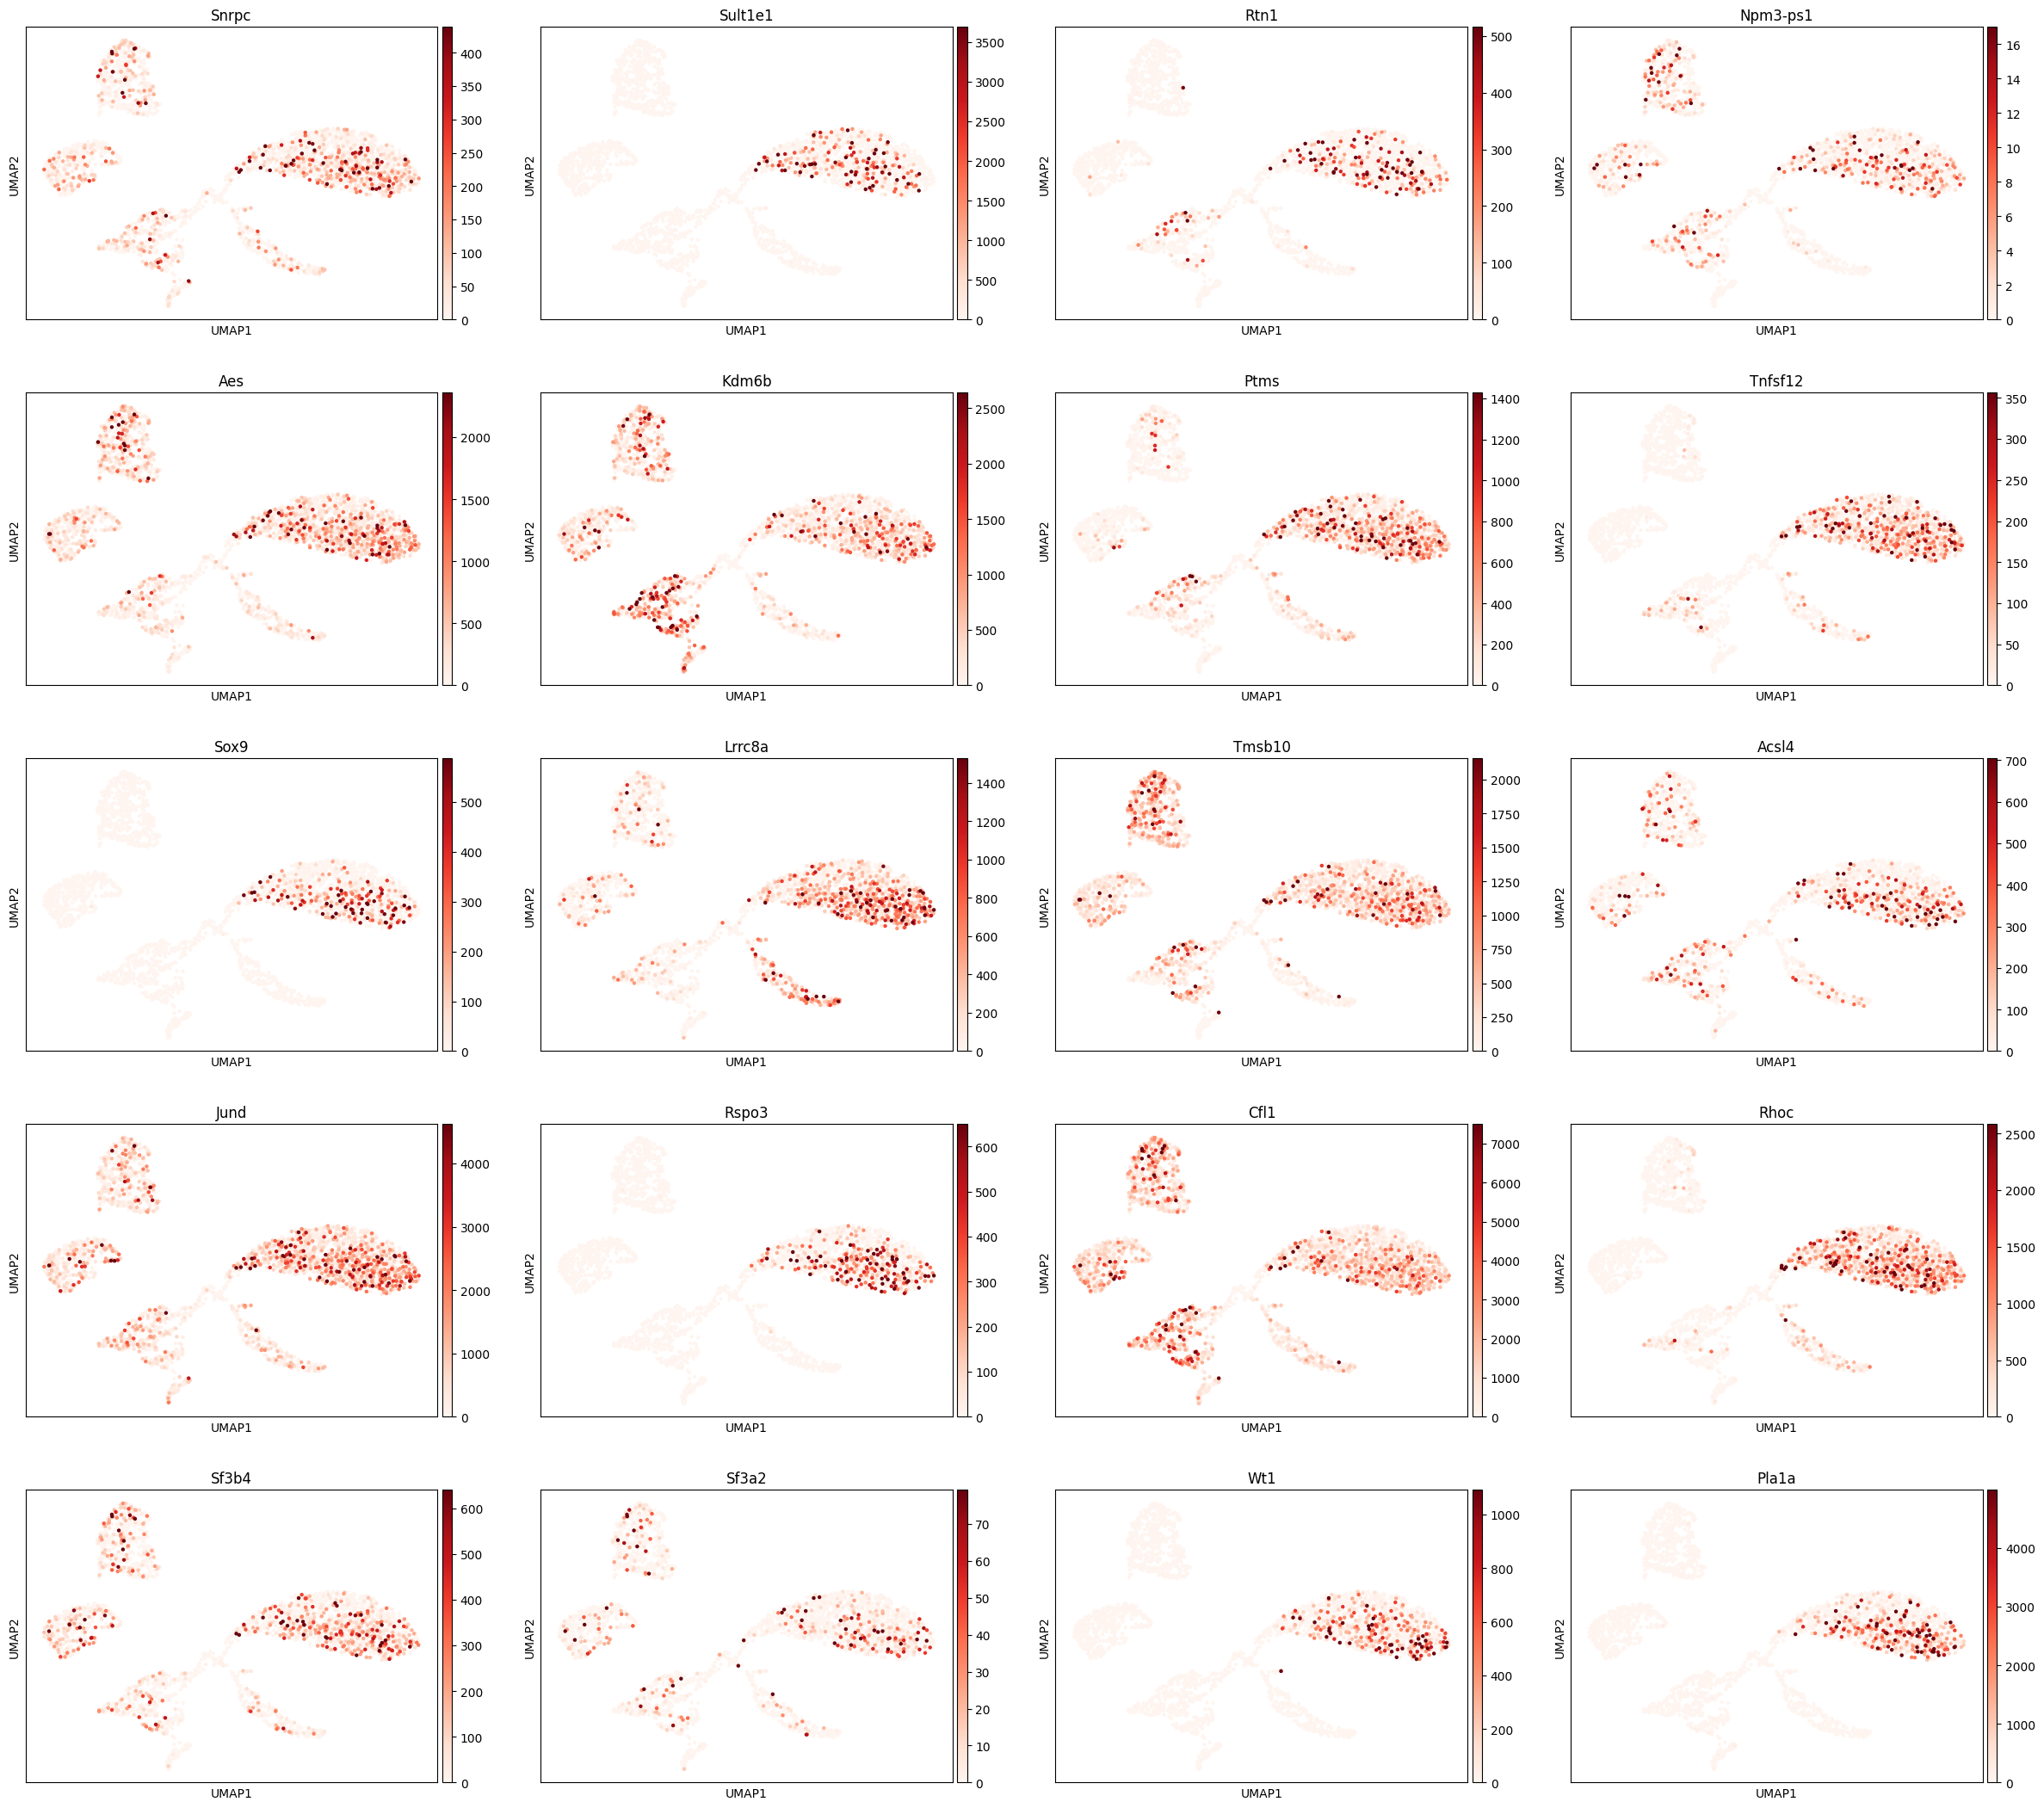

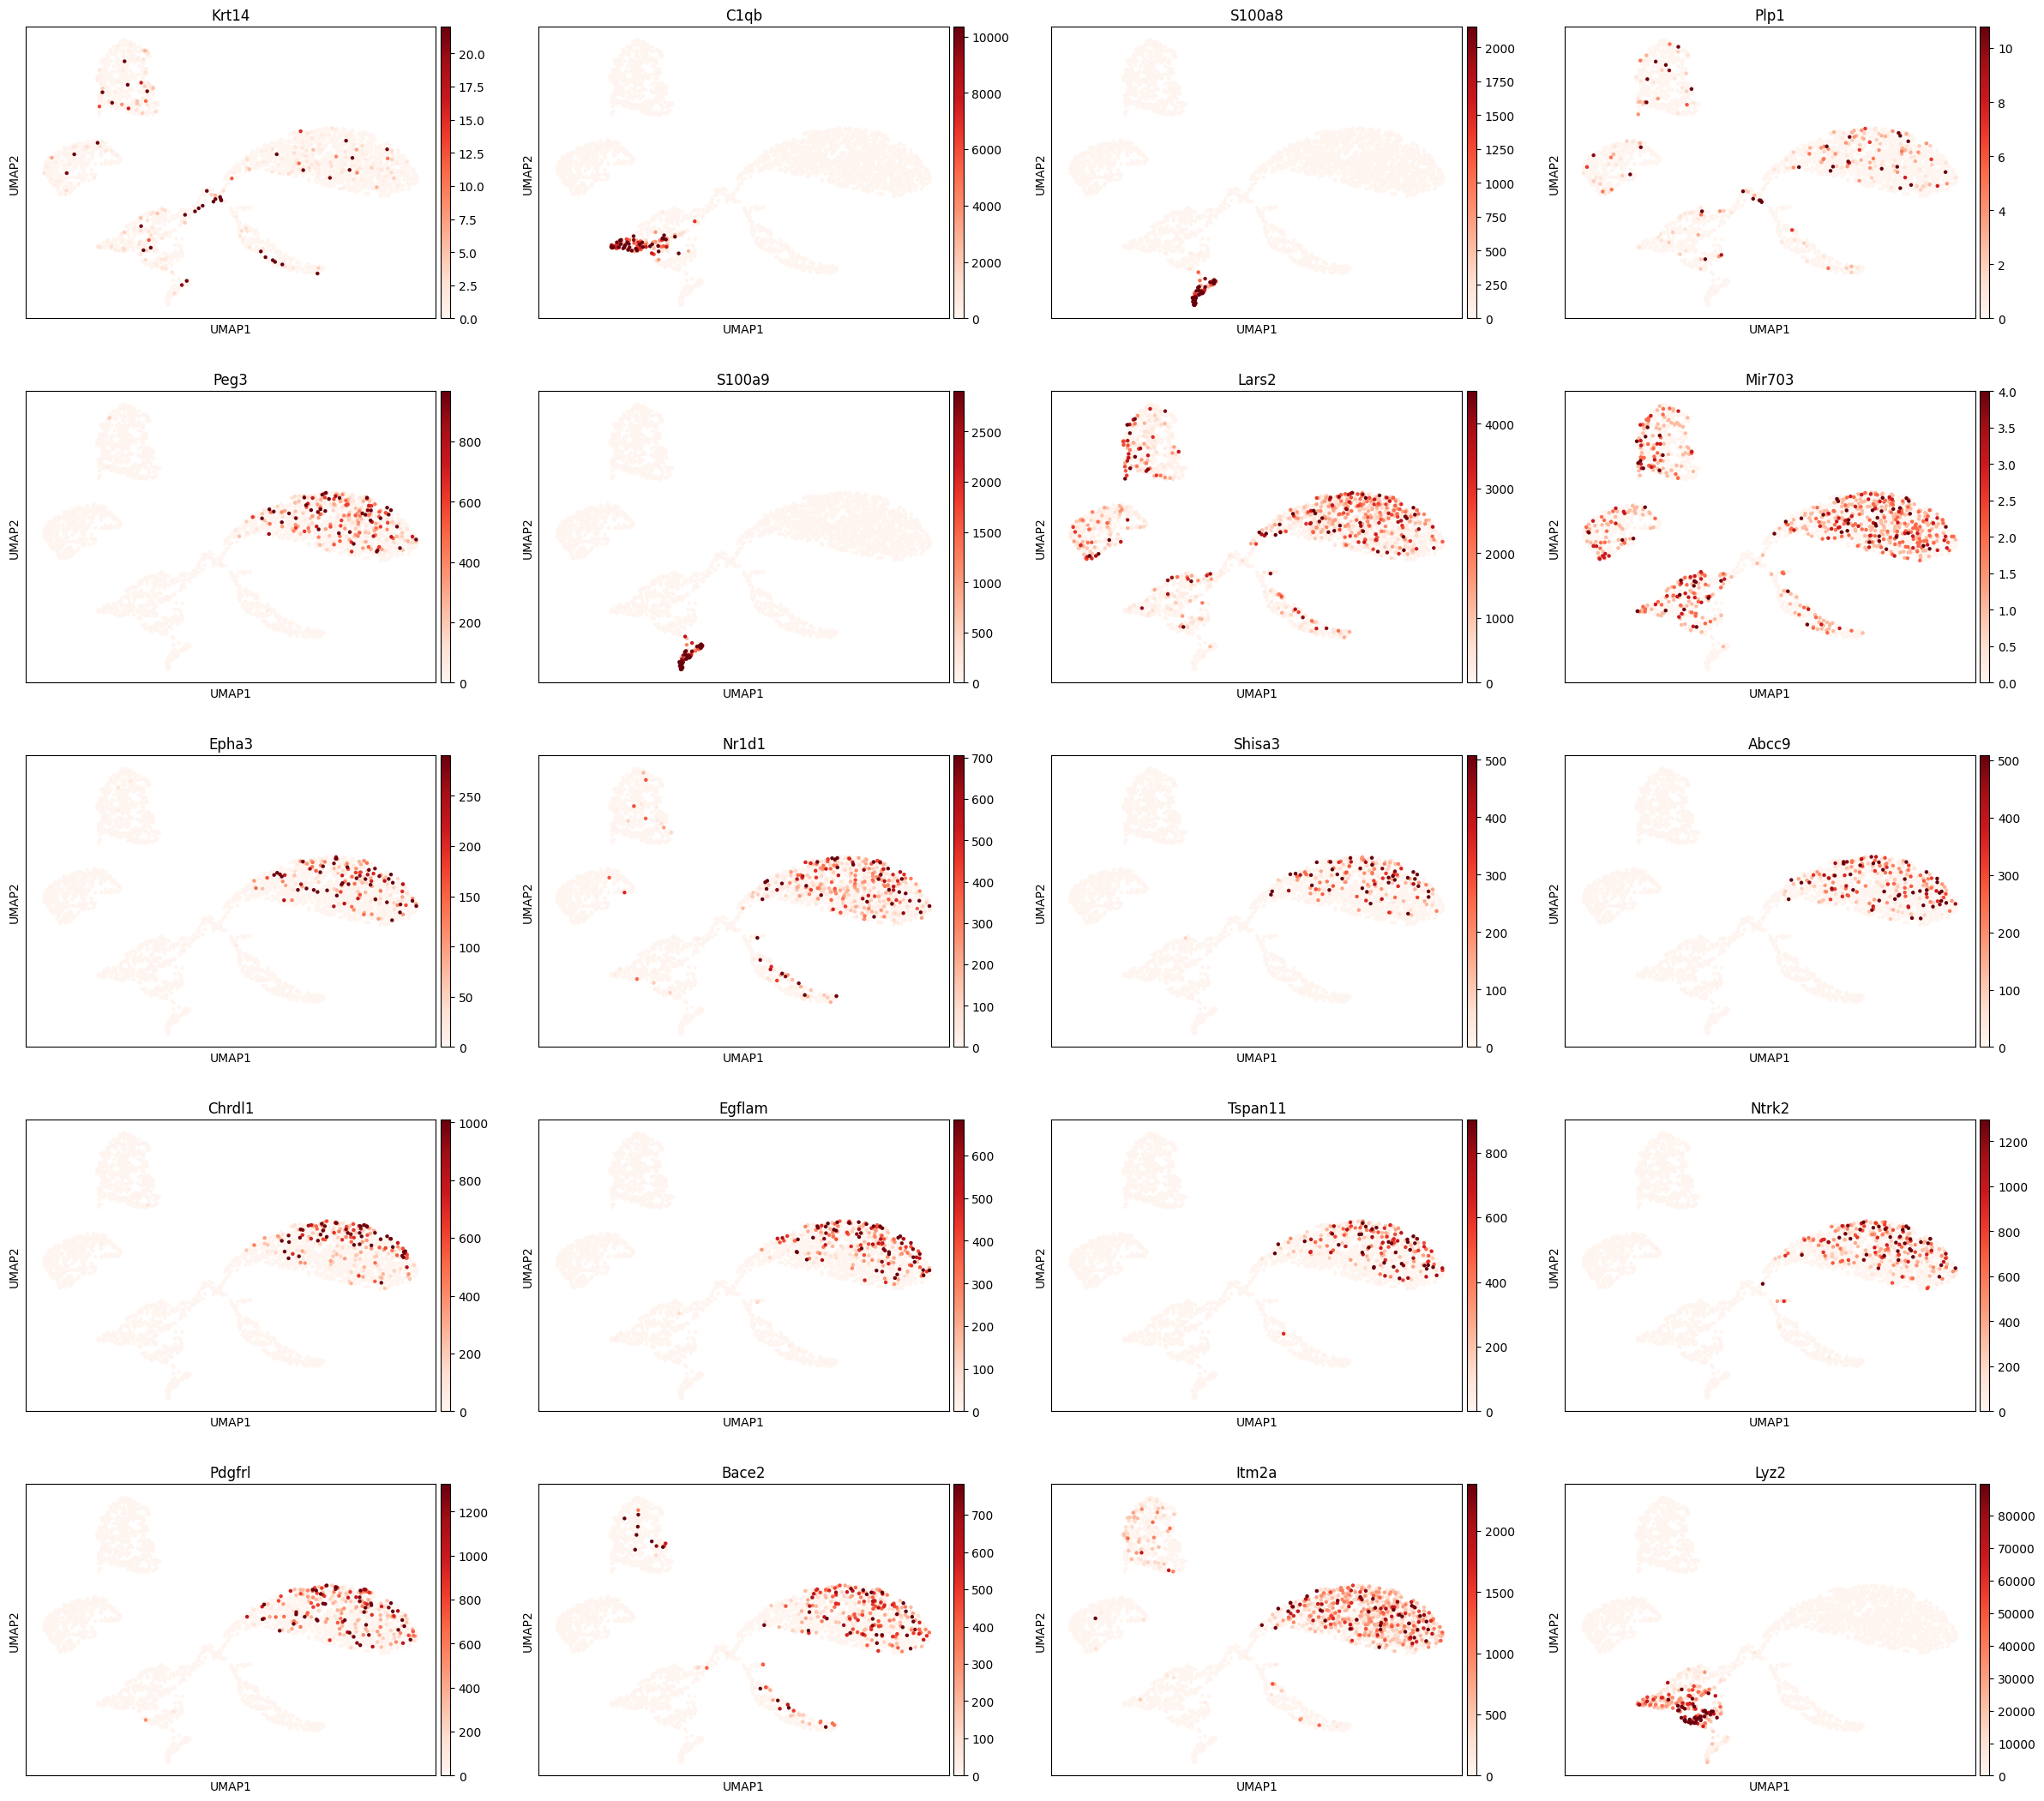

In [11]:
up_genes = [
    'Snrpc', 'Sult1e1', 'Rtn1', 'Npm3-ps1', 'Aes', 'Kdm6b', 'Ptms',
    'Tnfsf12', 'Sox9', 'Lrrc8a', 'Tmsb10', 'Acsl4', 'Jund', 'Rspo3',
    'Cfl1', 'Rhoc', 'Sf3b4', 'Sf3a2', 'Wt1', 'Pla1a'
]

sc.pl.umap(
    adata_aging,
    color=up_genes,
    cmap='Reds',
    vmax='p99',
    ncols=4,
    title=up_genes
)

down_genes = [
    'Krt14', 'C1qb', 'S100a8', 'Plp1', 'Peg3', 'S100a9', 'Lars2',
    'Mir703', 'Epha3', 'Nr1d1', 'Shisa3', 'Abcc9', 'Chrdl1', 'Egflam',
    'Tspan11', 'Ntrk2', 'Pdgfrl', 'Bace2', 'Itm2a', 'Lyz2'
]

sc.pl.umap(
    adata_aging,
    color=down_genes,
    cmap='Reds',
    vmax='p99',
    ncols=4,
    title=down_genes
)

Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):
       18m_n     18m_l          18m_p
0      Snrpc  3.271004   7.074236e-36
1    Sult1e1  3.230292   6.156568e-10
2       Rtn1  2.940339   8.843024e-11
3   Npm3-ps1  2.613997   1.137239e-12
4        Aes  2.603688  1.261284e-104
5      Kdm6b  2.537529   1.009264e-73
6       Ptms  2.510277   8.203943e-75
7    Tnfsf12  2.478673   3.811281e-26
8       Sox9  2.477952   1.361488e-09
9     Lrrc8a  2.434525   2.072057e-58
10    Tmsb10  2.328300  3.097018e-129
11     Acsl4  2.254771   5.686194e-13
12      Jund  2.243318   1.269268e-86
13     Rspo3  2.218304   1.243007e-13
14      Cfl1  2.208636  5.457530e-130
15      Rhoc  2.155695   5.526976e-71
16     Sf3b4  2.128381   1.241787e-13
17     Sf3a2  2.125204   5.734671e-06
18       Wt1  2.087158   6.831500e-13
19     Pla1a  2.075122   4.785475e-17


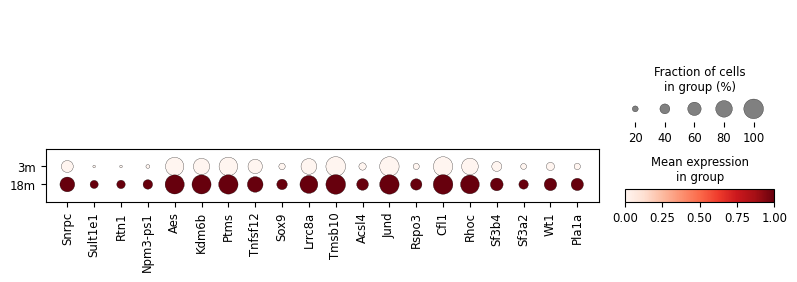

Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):
            18m_n     18m_l         18m_p
0            Peg3 -3.489405  1.087597e-25
1           Lars2 -3.146296  2.903027e-51
2          Mir703 -2.983210  4.024947e-22
3           Epha3 -2.802194  2.174110e-07
4           Nr1d1 -2.795506  1.828156e-16
5          Shisa3 -2.622792  3.494040e-06
6           Abcc9 -2.549817  1.850909e-11
7          Chrdl1 -2.463960  1.919852e-06
8          Egflam -2.421206  5.560884e-12
9         Tspan11 -2.392922  1.062292e-13
10          Ntrk2 -2.270074  2.033548e-09
11         Pdgfrl -2.013982  4.738629e-07
12          Bace2 -1.970781  1.706130e-06
13          Itm2a -1.960922  2.427211e-35
14          Matn2 -1.810086  2.425197e-16
15          Rps29 -1.795150  2.059535e-84
16  E030003E18Rik -1.712770  1.256871e-09
17        Aldh1a1 -1.679214  8.345185e-14
18         Igsf10 -1.627213  6.797024e-14
19          Cdh13 -1.626794  8.384872e-15


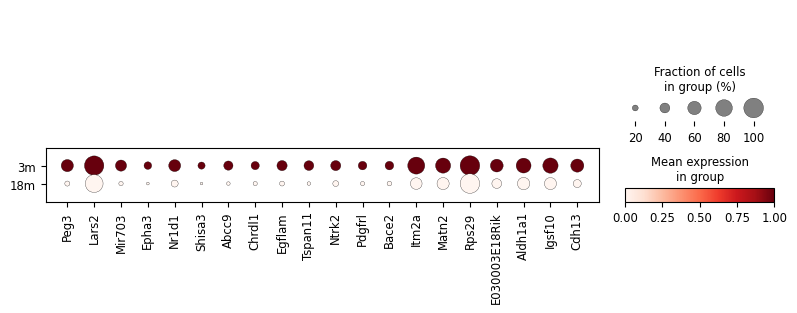

In [12]:
import pandas as pd
sc.tl.rank_genes_groups(
    mesenchymal_stem_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = mesenchymal_stem_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

blacklist = ('Krt', 'S100', 'C1q', 'Lyz2', 'Plp1')
dataframe = dataframe[~dataframe['18m_n'].str.startswith(blacklist)]

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.5) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated mesenchymal stem cell of adipose Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = mesenchymal_stem_cells[mesenchymal_stem_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.5) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated mesenchymal stem cell of adipose Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = mesenchymal_stem_cells[mesenchymal_stem_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

Top 10 Upregulated Pathways in Aged mesenchymal stem cell of adipose:
                                                Term  Adjusted P-value Overlap
0  Negative Regulation of Apoptotic Process (GO:0...          0.020554  20/475
1                       mRNA Processing (GO:0006397)          0.020554  13/226
2  Positive Regulation of Endothelial Cell Migrat...          0.020554    8/88
3  RNA Splicing, via Transesterification Reaction...          0.020554  11/171
4       Morphogenesis of an Endothelium (GO:0003159)          0.020554     3/6
5                          RNA Splicing (GO:0008380)          0.020554    8/92
6        mRNA Splicing, via Spliceosome (GO:0000398)          0.020949  12/211
7   Positive Regulation of Angiogenesis (GO:0045766)          0.023839   9/126
8                        RNA Processing (GO:0006396)          0.023839  14/291
9                mRNA Metabolic Process (GO:0016071)          0.023839   8/101


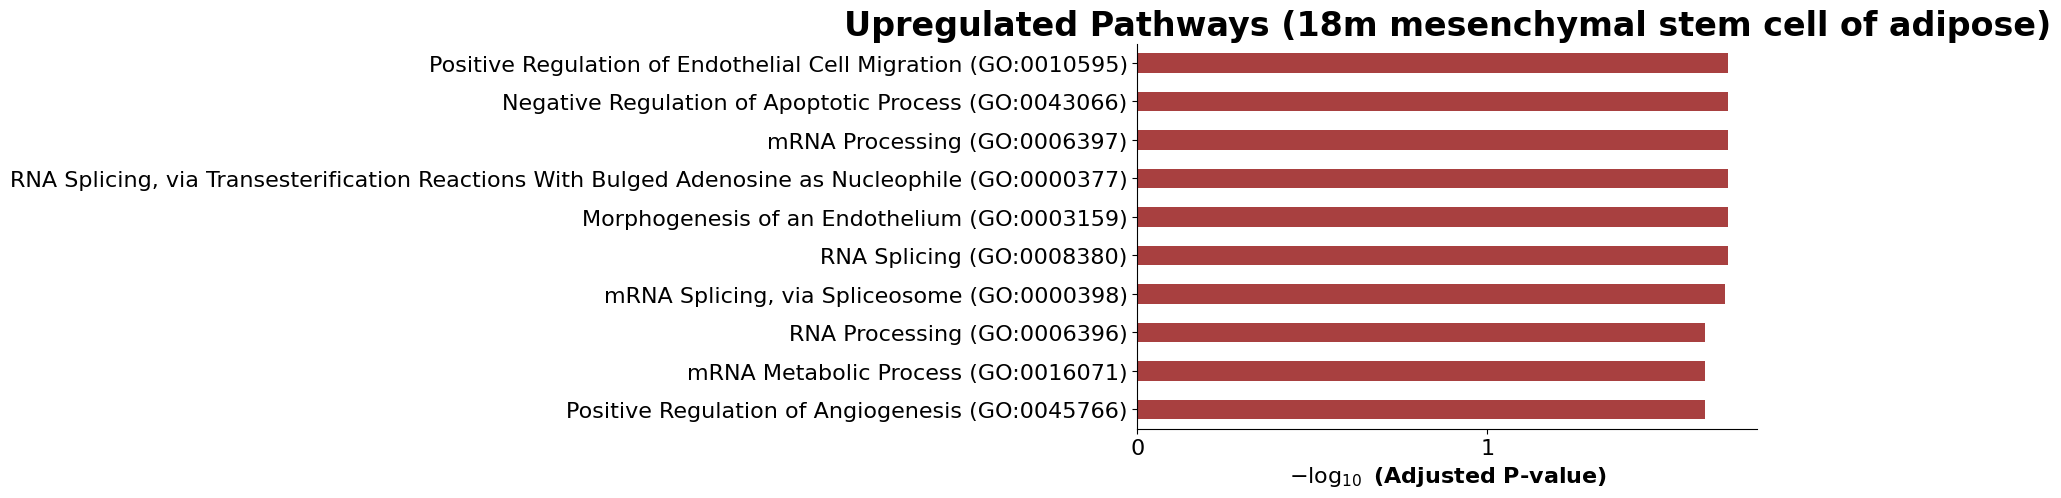

In [13]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.25) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-3].sort_values(by='18m_l', ascending=False).reset_index(drop=True)

clean_up_genes = final_up_df['18m_n'].head(300).tolist()
enr_up = gp.enrichr(
    gene_list=clean_up_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_up_df = enr_up.results
print("Top 10 Upregulated Pathways in Aged mesenchymal stem cell of adipose:")
print(results_up_df[['Term', 'Adjusted P-value', 'Overlap']].head(10))
gp.barplot(
    enr_up.results,
    column="Adjusted P-value",
    title='Upregulated Pathways (18m mesenchymal stem cell of adipose)',
    top_term=10,
    figsize=(8, 5),
    color='darkred'
)
plt.show()